In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from locomotif import locomotif
from sub_tsmd import apply_sub_tsmd

### Utility methods

In [2]:
def size_constraint(discovered_motif_sets, min_nb_imu):
    return [
        (mask, motif_set)
        for mask, motif_set in discovered_motif_sets
        if mask.sum() >= min_nb_imu * 3
    ]

In [3]:
def get_mask_per_imu(X):
    mask_per_imu = []
    for i in range(3):
        mask = np.zeros(X.shape[1], dtype=bool)
        mask[np.arange(3) + i*3] = True
        mask_per_imu.append(mask)
    return mask_per_imu


def apply_locomotif_per_imu(X, margin: float = 0.0, **kwargs):
    start_mask = np.ones(X.shape[0], dtype=bool)
    if margin > 0:
        start_mask[:int(X.shape[0]*margin)] = False
        start_mask[-int(X.shape[0]*margin):] = False
    end_mask = start_mask.copy()
    return [
        [
            (mask, np.repeat(np.expand_dims(np.array(motif_set), axis=-1), mask.sum(), axis=-1))
            for (_, motif_set) in locomotif.apply_locomotif(X[:, mask], **kwargs, start_mask=start_mask.copy(), end_mask=end_mask.copy())
        ]
        for mask in get_mask_per_imu(X)
    ]

In [48]:
def draw_figure(X, time, y, figsize=(15, 5), motif_set_id=None, other_motif_set=None, other_X=None, zoom_min=0.0, zoom_max=1.0, x_ticks_motifs=None) -> plt.Figure:
    sns.set_theme()
    
    width_ratios = [1]
    if motif_set_id is not None:
        width_ratios += [0.2]
    if other_motif_set is not None:
        width_ratios += [0.2]
    f, axs = plt.subplots(3, len(width_ratios), figsize=figsize, sharex='col', sharey='row', squeeze=False, width_ratios=width_ratios)
    
    for ax in axs.flatten():
        ax.set_prop_cycle(color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:3])

    for ax, mask in zip(axs[:, 0], get_mask_per_imu(X)):
        ax.plot((time - time.min()).total_seconds(), X[:, mask])
        ax.set_yticks([])
        
    for ax, imu_label in zip(axs[:, 0], ['wrist', 'Chest', 'Ankle']):
        ax.set_ylabel(imu_label, fontsize=16)
        
    # Mark the motifs
    color_cycle = [cm.jet(x) for x in np.linspace(0.0, 1.0, len(y))]
    for i, (mask, motif_set) in enumerate(y):
        c = 0
        for d in range(3):
            if not mask[d*3]:
                continue

            for j in range(motif_set.shape[0]):
                axs[d, 0].axvspan(
                    (time[motif_set[j, 0, c].astype(int)] - time.min()).total_seconds(),
                    (time[min(motif_set[j, 1, c].astype(int), time.shape[0]-1)] - time.min()).total_seconds(),
                    color=color_cycle[i],
                    alpha=0.5,
                )
            c += 1
            
    # Plot a motif   
    if motif_set_id is not None:
        for i, motif in enumerate(y[motif_set_id][1]):
            c = 0
            masks = get_mask_per_imu(X)
            for d, mask in enumerate(masks):
                if not y[motif_set_id][0][d*3]:
                    continue
                motif_data = X[motif[0, c].astype(int):motif[1, c].astype(int), mask]
                motif_time = time[motif[0, c].astype(int):motif[1, c].astype(int)]
                axs[d, 1].plot((motif_time - motif_time.min()).total_seconds(), motif_data, alpha=1 if i==0 else 0.5)
                c += 1

        if x_ticks_motifs is not None:
            axs[0, 1].set_xticks(x_ticks_motifs)
                
    # Plot another motif
    if other_motif_set is not None:
        other_mask, other_motifs = other_motif_set
        for i, motif in enumerate(other_motifs):
            c = 0
            masks = get_mask_per_imu(other_X)
            for d, mask in enumerate(masks):
                if not other_mask[d*3]:
                    continue
                motif_data = other_X[motif[0, c].astype(int):motif[1, c].astype(int), mask]
                motif_time = time[motif[0, c].astype(int):motif[1, c].astype(int)]
                axs[d, 2].plot((motif_time - motif_time.min()).total_seconds(), motif_data, alpha=1 if i==0 else 0.5)
                c += 1
                
        if x_ticks_motifs is not None:
            axs[0, 2].set_xticks(x_ticks_motifs)

    max_x_lim = (time.max() - time.min()).total_seconds()
    axs[0, 0].set_xlim([max_x_lim*zoom_min, max_x_lim*zoom_max]) 
    f.supxlabel('Time [s]', fontsize=16)
    for ax in axs[-1]:
        ax.tick_params(axis='x', labelsize=16) # Hide the ticks for all but last axis

    f.legend(['x-acceleration', 'y-acceleration', 'z-acceleration'], loc='lower left', bbox_to_anchor=(0.045, 0.97), fontsize=16)
    f.tight_layout()
    
    return f


def save_figure(f, activity, extension = None):
    f.savefig(f'figures-paper/fig-activity-recognition-{activity}.{extension or "png"}', bbox_inches='tight')

### PAMAP2 dataset

##### Features

In [5]:
imu_attributes = [
    "temperature (°C)",
] + [
    f"{direction}-acceleration (m/s²)" for direction in ['x', 'y', 'z']
] + [
    f"{direction}-acceleration II (m/s²)" for direction in ['x', 'y', 'z']
] + [
    f"{direction}-gyroscope (rad/s)" for direction in ['x', 'y', 'z']
] + [
    f"{direction}-magnetometer (µT)" for direction in ['x', 'y', 'z']
] + [
    f"orientation {i}" for i in ['I', 'II', 'III', 'IV']
]
header = [
    "timestamp (s)",
    "activityID",
    "heart rate (bpm)"
] + [
    f'IMU wrist -> {attribute}' for attribute in imu_attributes
] + [
    f'IMU chest -> {attribute}' for attribute in imu_attributes
] + [
    f'IMU ankle -> {attribute}' for attribute in imu_attributes
]

In [6]:
relevant_features = [
    "activityID",
] + [
    f"IMU {imu_location} -> {direction}-{feature}"
    for imu_location in ["wrist", "chest", "ankle"]
    for feature in ["acceleration (m/s²)"]
    for direction in ["x", "y", "z"]
]

In [7]:
activities = {
    0: 'other',
    1: 'lying',
    2: 'sitting',
    3: 'standing',
    4: 'walking',
    5: 'running',
    6: 'cycling',
    7: 'Nordic walking',
    8: '???',
    9: 'watching TV',
    10: 'computer work',
    11: 'car driving',
    12: 'ascending stairs',
    13: 'descending stairs',
    14: '???',
    15: '???',
    16: 'vacuum cleaning',
    17: 'ironing',
    18: 'folding laundry',
    19: 'house cleaning',
    20: 'playing soccer',
    21: '???',
    22: '???',
    23: '???',
    24: 'rope jumping',
}

##### Loading the data

In [8]:
df_full = pd.read_csv(
    '../data/pamap2+physical+activity+monitoring/PAMAP2_Dataset/PAMAP2_Dataset/Protocol/subject101.dat',
    sep=' ', names=header, index_col='timestamp (s)'
)
df_full = df_full[relevant_features]
df_full.index = pd.to_timedelta(df_full.index, unit='s')
print(df_full.shape)
df_full.head()

(376417, 10)


,activityID,IMU wrist -> x-acceleration (m/s²),IMU wrist -> y-acceleration (m/s²),IMU wrist -> z-acceleration (m/s²),IMU chest -> x-acceleration (m/s²),IMU chest -> y-acceleration (m/s²),IMU chest -> z-acceleration (m/s²),IMU ankle -> x-acceleration (m/s²),IMU ankle -> y-acceleration (m/s²),IMU ankle -> z-acceleration (m/s²)
timestamp (s),,,,,,,,,,
0 days 00:00:08.380000,0,2.37223,8.60074,3.51048,0.238080,9.80003,-1.68896,9.65918,-1.65569,-0.099797
0 days 00:00:08.390000,0,2.18837,8.56560,3.66179,0.319530,9.61282,-1.49328,9.69370,-1.57902,-0.215687
0 days 00:00:08.400000,0,2.37357,8.60107,3.54898,0.235593,9.72421,-1.76621,9.58944,-1.73276,0.092914
0 days 00:00:08.410000,0,2.07473,8.52853,3.66021,0.388697,9.53572,-1.72410,9.58814,-1.77040,0.054545
0 days 00:00:08.420000,0,2.22936,8.83122,3.70000,0.315800,9.49908,-1.60914,9.69771,-1.65625,-0.060809


In [9]:
df = df_full.resample('0.05s').mean()
df['activityID'] = df['activityID'].round(decimals=0).astype(int).map(activities)
one_second_window = 1 / df.index.to_series().diff().mean().total_seconds()
print(one_second_window, df.shape)
df.head()

20.0 (75284, 10)


,activityID,IMU wrist -> x-acceleration (m/s²),IMU wrist -> y-acceleration (m/s²),IMU wrist -> z-acceleration (m/s²),IMU chest -> x-acceleration (m/s²),IMU chest -> y-acceleration (m/s²),IMU chest -> z-acceleration (m/s²),IMU ankle -> x-acceleration (m/s²),IMU ankle -> y-acceleration (m/s²),IMU ankle -> z-acceleration (m/s²)
timestamp (s),,,,,,,,,,
0 days 00:00:08.380000,other,2.247652,8.625432,3.616292,0.299540,9.634372,-1.656338,9.645634,-1.678824,-0.045767
0 days 00:00:08.430000,other,2.321512,8.987990,3.493014,0.286413,9.657478,-1.586950,9.721566,-1.641584,-0.014347
0 days 00:00:08.480000,other,2.423046,8.834614,3.402682,0.332091,9.634746,-1.586052,9.714300,-1.641604,-0.006704
0 days 00:00:08.530000,other,2.399354,8.955724,3.348034,0.283956,9.679502,-1.672254,9.706836,-1.679588,0.001173
0 days 00:00:08.580000,other,2.452470,9.137156,3.317432,0.254797,9.664848,-1.626270,9.660626,-1.716952,-0.037658


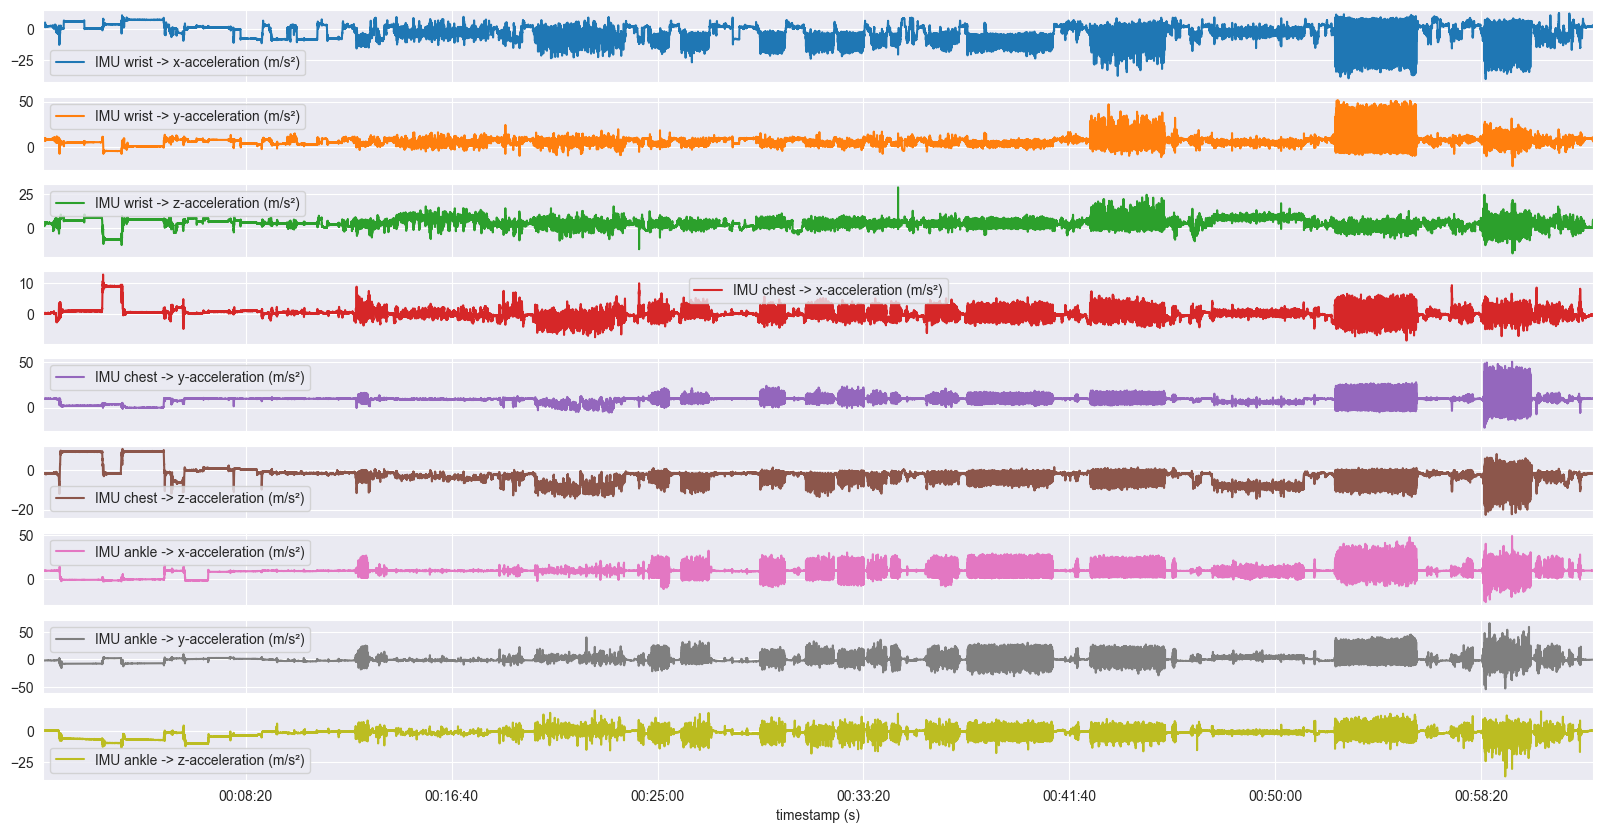

In [10]:
df.plot(figsize=(20, 10), subplots=True);

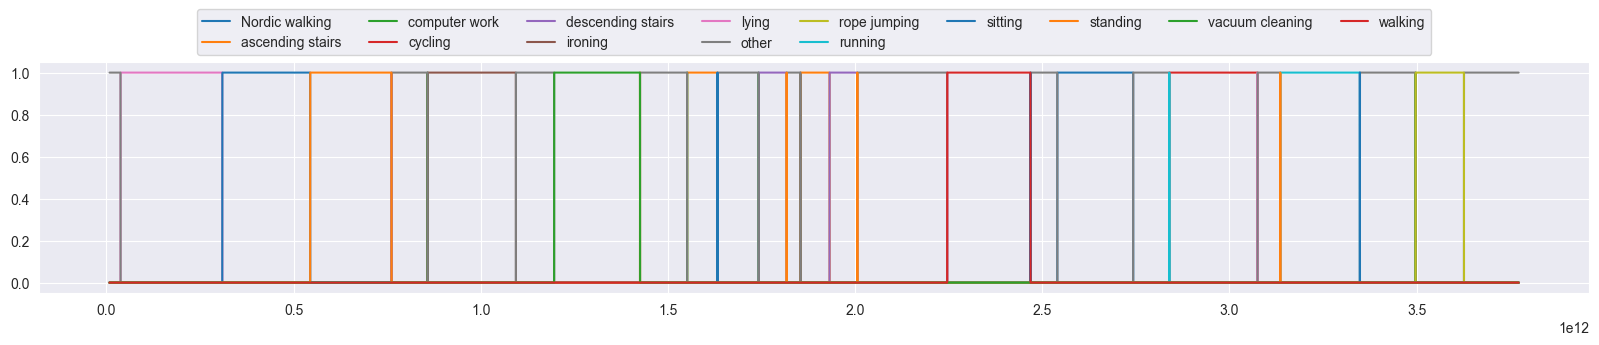

In [11]:
plt.figure(figsize=(20, 3))
plt.plot(pd.get_dummies(df['activityID']))
plt.legend(pd.get_dummies(df['activityID']).columns, loc='lower center', bbox_to_anchor=(0.5, 1), ncols=9);

In [12]:
df_tmp = df.copy()
df_tmp['change'] = df_tmp['activityID'].ne(df_tmp['activityID'].shift()).cumsum()
grouped = df_tmp.groupby('change')
all_segments = [group.drop(columns='change') for _, group in grouped if group.shape[0] > 20]

for segment_id, segment in enumerate(all_segments):
    print(f"Segment {segment_id}: {segment['activityID'].iloc[0]} {segment.shape}")

Segment 0: other (586, 10)
Segment 1: lying (5437, 10)
Segment 2: sitting (4696, 10)
Segment 3: standing (4343, 10)
Segment 4: other (1930, 10)
Segment 5: ironing (4714, 10)
Segment 6: other (2044, 10)
Segment 7: vacuum cleaning (4588, 10)
Segment 8: other (2515, 10)
Segment 9: ascending stairs (1623, 10)
Segment 10: other (2198, 10)
Segment 11: descending stairs (1495, 10)
Segment 12: other (736, 10)
Segment 13: ascending stairs (1553, 10)
Segment 14: descending stairs (1484, 10)
Segment 15: other (4800, 10)
Segment 16: walking (4450, 10)
Segment 17: other (1432, 10)
Segment 18: Nordic walking (4053, 10)
Segment 19: other (1931, 10)
Segment 20: cycling (4714, 10)
Segment 21: other (1213, 10)
Segment 22: running (4252, 10)
Segment 23: other (2975, 10)
Segment 24: rope jumping (2582, 10)
Segment 25: other (2924, 10)


In [13]:
segments_df = {
    'Ironing': all_segments[7],
    'Vacuum cleaning': all_segments[5],
    'Ascending stairs': all_segments[13],
    'Descending stairs': all_segments[14],
    'Walking': all_segments[16],
    'Nordic walking': all_segments[18],
    'Cycling': all_segments[20],
    'Running': all_segments[22],
    'Rope jumping': all_segments[24],
}
segments = {activity: segment.drop(columns='activityID').values for activity, segment in segments_df.items()}

for activity, segment in segments_df.items():
    print('>>>', activity)
    print('Shape:', segment.shape)
    print('Total time:', segment.index.max() - segment.index.min())
    print()

>>> Ironing
Shape: (4588, 10)
Total time: 0 days 00:03:49.350000

>>> Vacuum cleaning
Shape: (4714, 10)
Total time: 0 days 00:03:55.650000

>>> Ascending stairs
Shape: (1553, 10)
Total time: 0 days 00:01:17.600000

>>> Descending stairs
Shape: (1484, 10)
Total time: 0 days 00:01:14.150000

>>> Walking
Shape: (4450, 10)
Total time: 0 days 00:03:42.450000

>>> Nordic walking
Shape: (4053, 10)
Total time: 0 days 00:03:22.600000

>>> Cycling
Shape: (4714, 10)
Total time: 0 days 00:03:55.650000

>>> Running
Shape: (4252, 10)
Total time: 0 days 00:03:32.550000

>>> Rope jumping
Shape: (2582, 10)
Total time: 0 days 00:02:09.050000



### Ironing

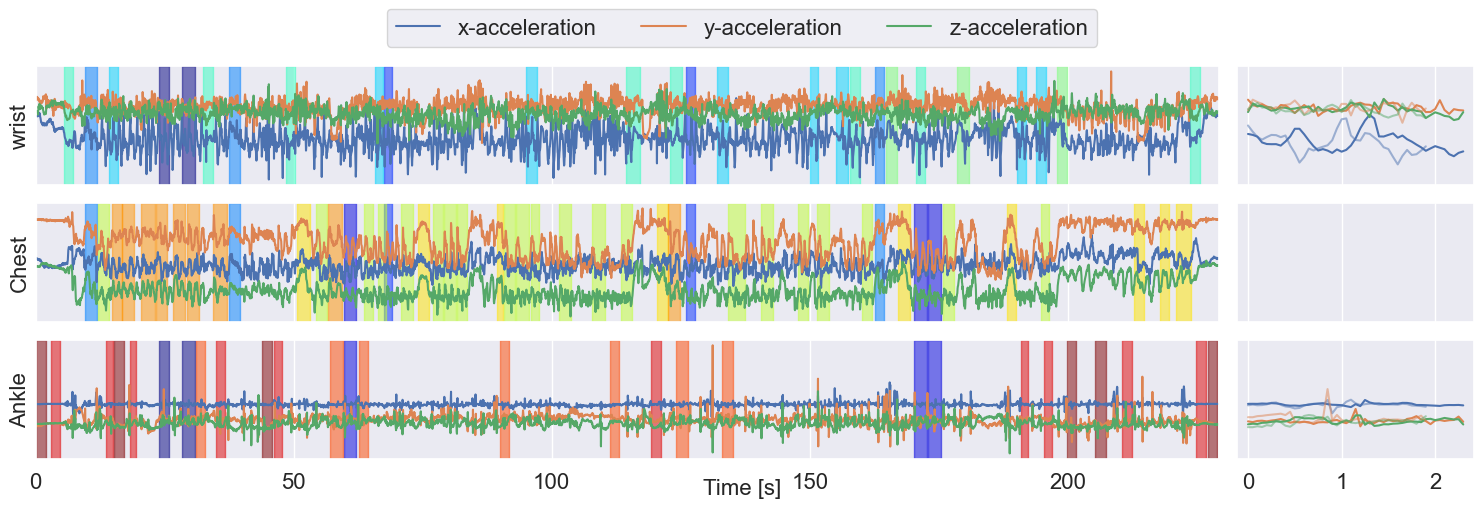

In [14]:
grouped_motifs_ironing = apply_locomotif_per_imu(
    segments['Ironing'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.8,
    warping=True,
    nb=3
)
all_motifs_ironing = apply_sub_tsmd(
    grouped_motifs_ironing, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Ironing'], segments_df['Ironing'].index, all_motifs_ironing, motif_set_id=0);

### Vacuum cleaning

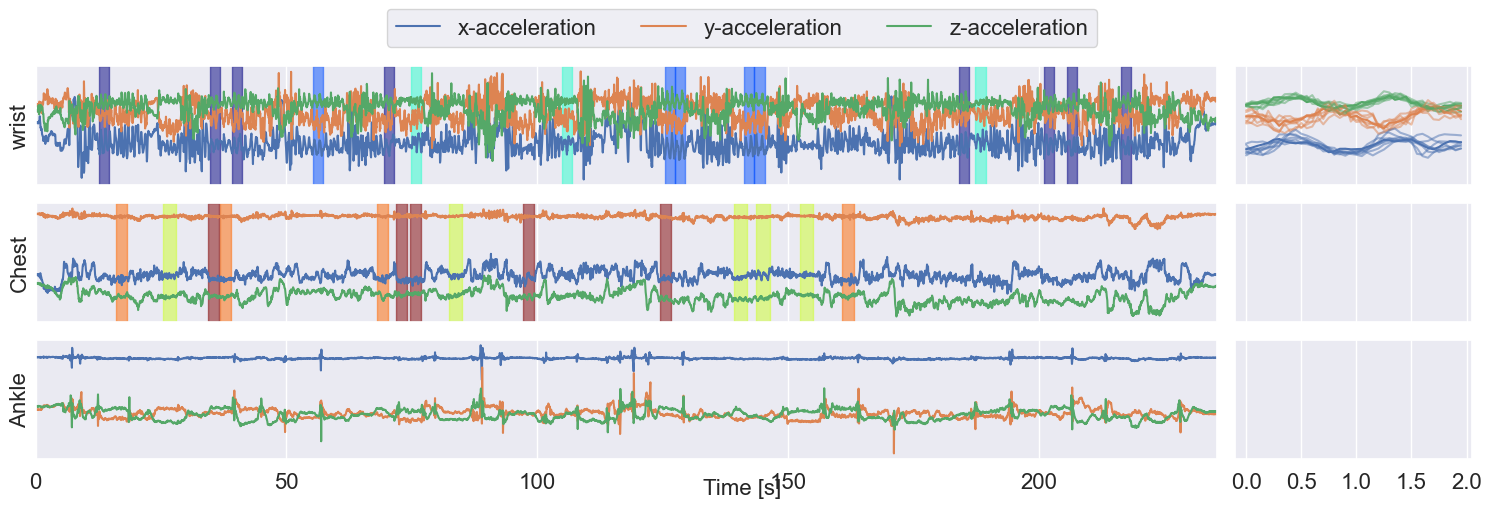

In [15]:
grouped_motifs_vacuum_cleaning = apply_locomotif_per_imu(
    segments['Vacuum cleaning'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.8,
    warping=False,
    nb=3,
    margin=0.05
)
all_motifs_vacuum_cleaning = apply_sub_tsmd(
    grouped_motifs_vacuum_cleaning, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Vacuum cleaning'], segments_df['Vacuum cleaning'].index, all_motifs_vacuum_cleaning, motif_set_id=0);

### Ascending stairs

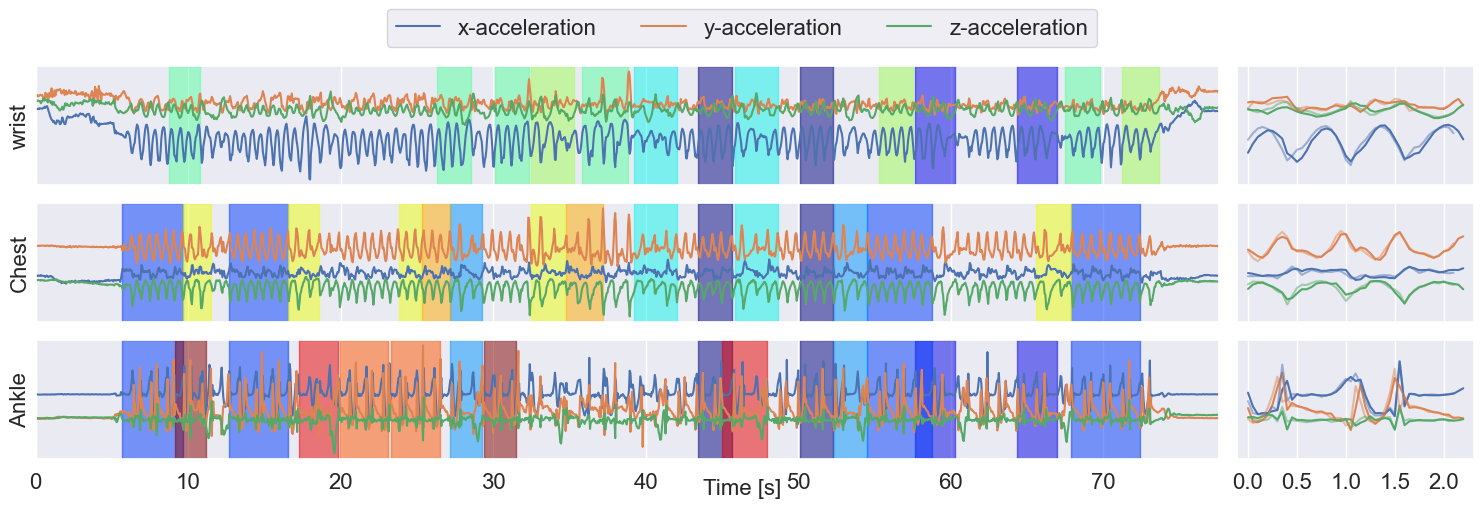

In [16]:
grouped_motifs_ascending_stairs = apply_locomotif_per_imu(
    segments['Ascending stairs'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.7,
    warping=True,
    nb=3,
    margin=0.05
)
all_motifs_ascending_stairs = apply_sub_tsmd(
    grouped_motifs_ascending_stairs, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Ascending stairs'], segments_df['Ascending stairs'].index, all_motifs_ascending_stairs, motif_set_id=0);

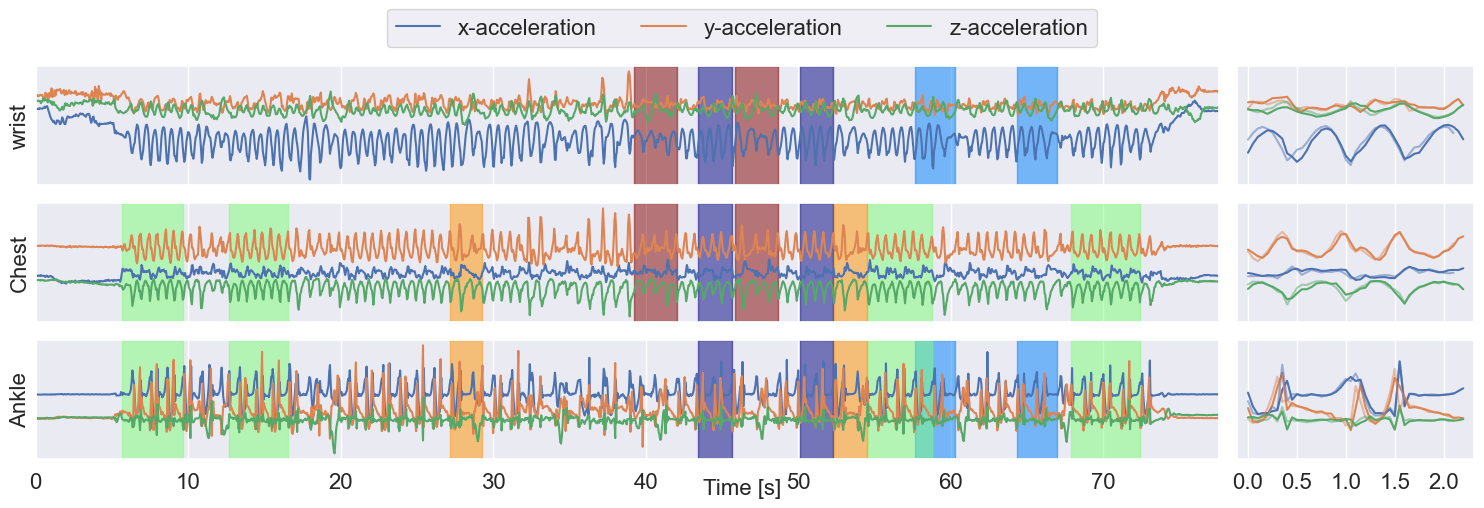

In [17]:
filtered_motifs_ascending_stairs = size_constraint(all_motifs_ascending_stairs, 2)
draw_figure(segments['Ascending stairs'], segments_df['Ascending stairs'].index, filtered_motifs_ascending_stairs, motif_set_id=0);

### Descending stairs

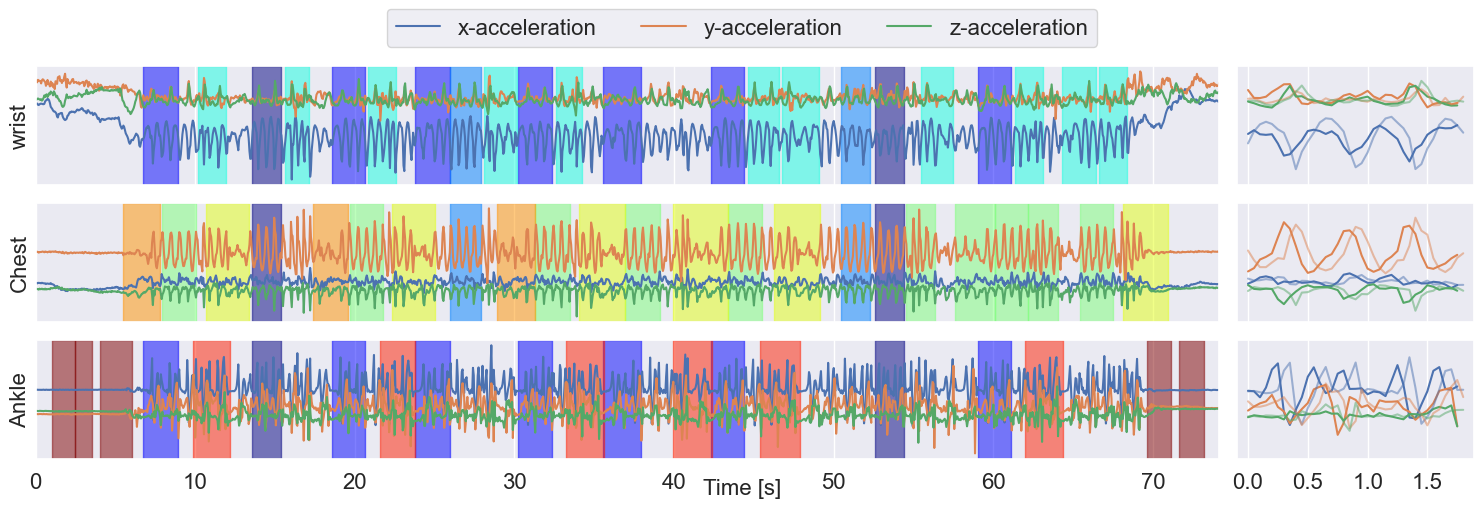

In [18]:
grouped_motifs_descending_stairs = apply_locomotif_per_imu(
    segments['Descending stairs'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.7,
    warping=True,
    nb=3,
    margin=0.05
)
all_motifs_descending_stairs = apply_sub_tsmd(
    grouped_motifs_descending_stairs, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Descending stairs'], segments_df['Descending stairs'].index, all_motifs_descending_stairs, motif_set_id=0);

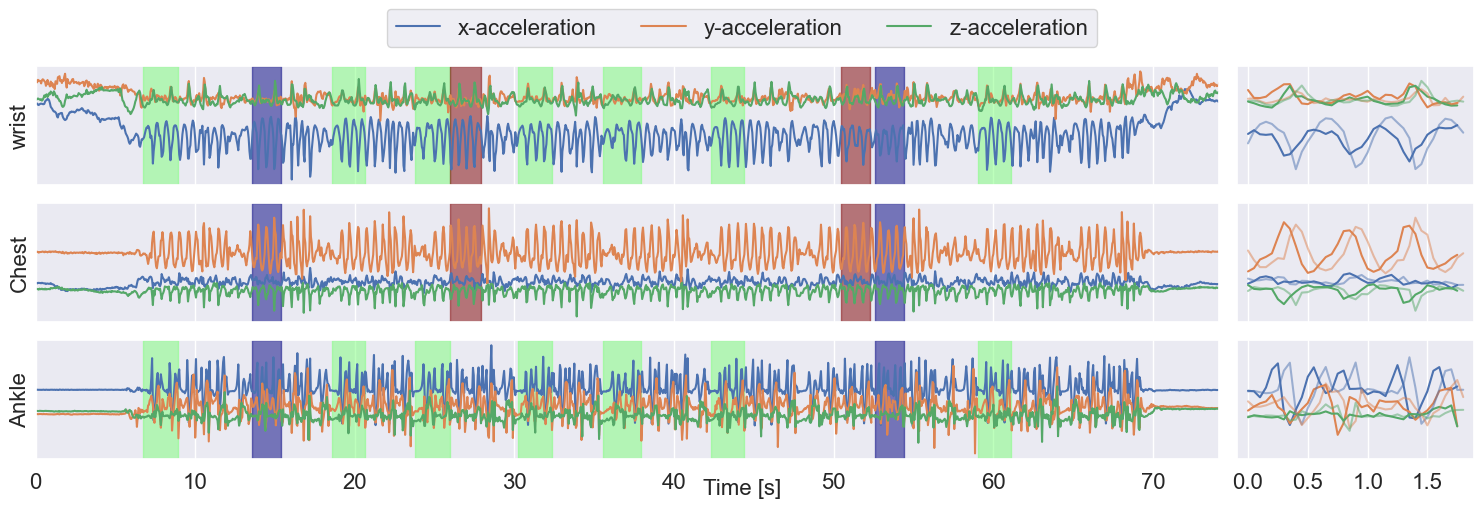

In [19]:
filtered_motifs_descending_stairs = size_constraint(all_motifs_descending_stairs, 2)
draw_figure(segments['Descending stairs'], segments_df['Descending stairs'].index, filtered_motifs_descending_stairs, motif_set_id=0);

### Walking

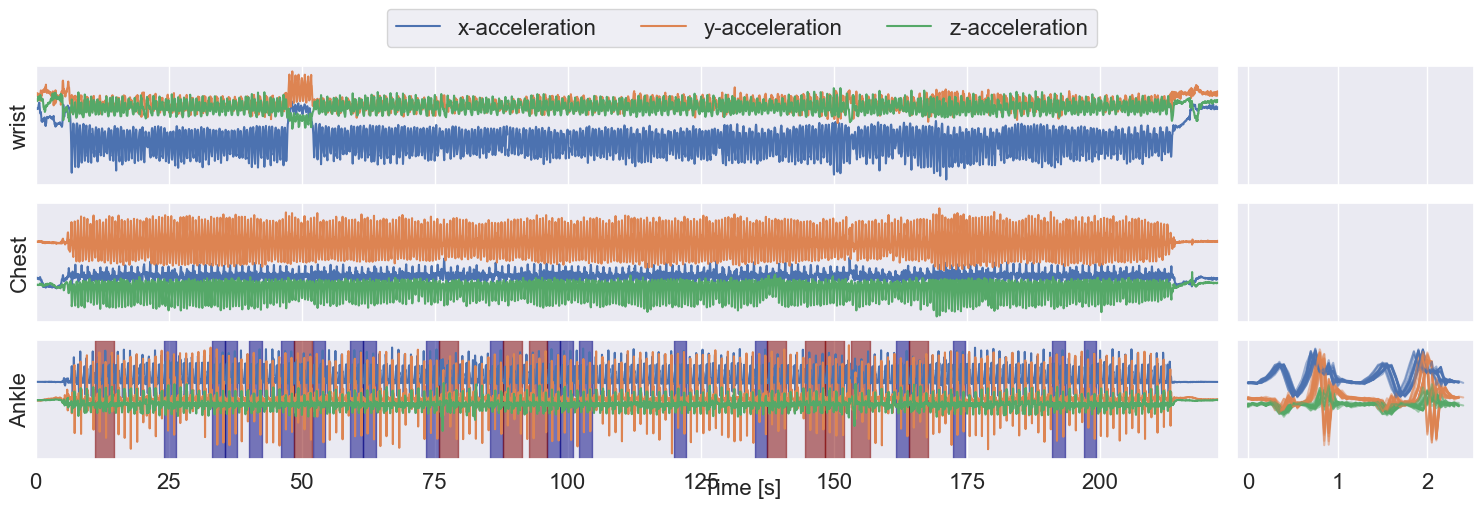

In [20]:
grouped_motifs_walking = apply_locomotif_per_imu(
    segments['Walking'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.7,
    warping=True,
    nb=3,
    margin=0.05
)
all_motifs_walking = apply_sub_tsmd(
    grouped_motifs_walking, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Walking'], segments_df['Walking'].index, all_motifs_walking, motif_set_id=0);

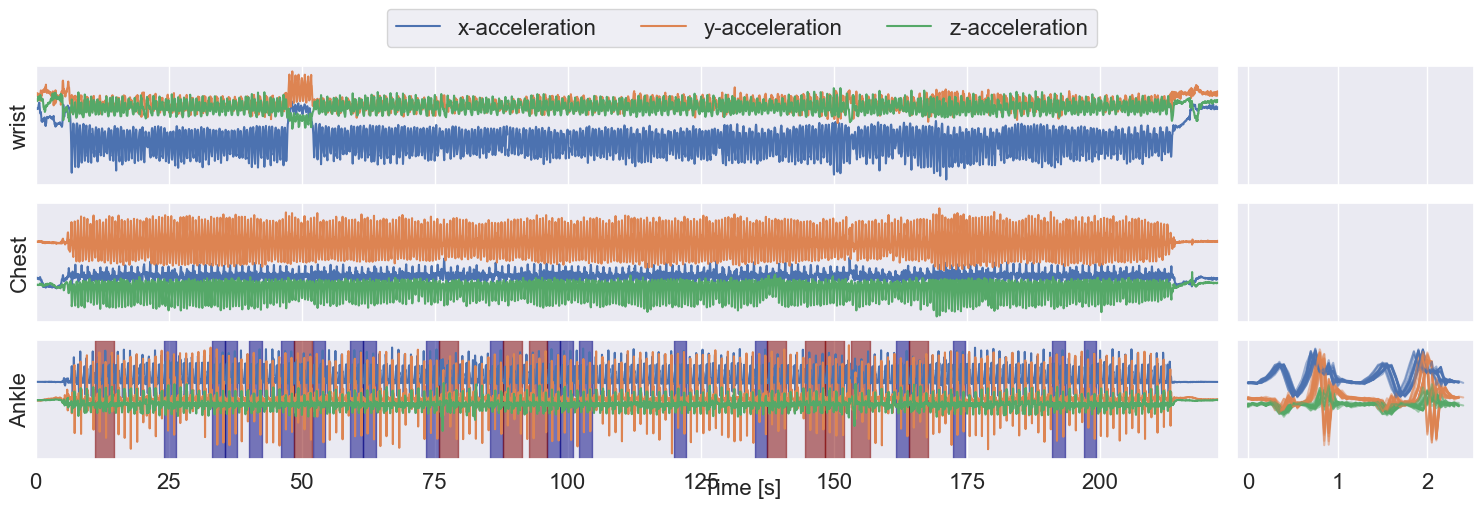

In [21]:
filtered_motifs_walking = size_constraint(all_motifs_walking, 1)
draw_figure(segments['Walking'], segments_df['Walking'].index, filtered_motifs_walking, motif_set_id=0);

### Nordic walking

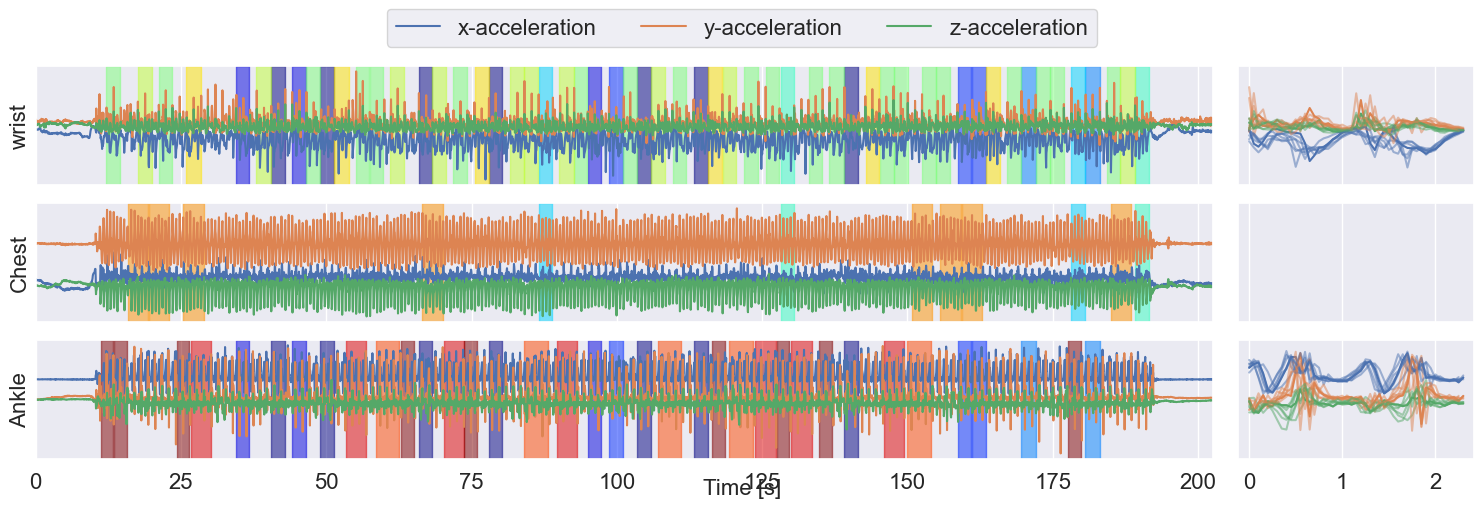

In [22]:
grouped_motifs_nordic_walking = apply_locomotif_per_imu(
    segments['Nordic walking'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.7,
    warping=True,
    nb=3,
    margin=0.05
)
all_motifs_nordic_walking = apply_sub_tsmd(
    grouped_motifs_nordic_walking, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Nordic walking'], segments_df['Nordic walking'].index, all_motifs_nordic_walking, motif_set_id=0);

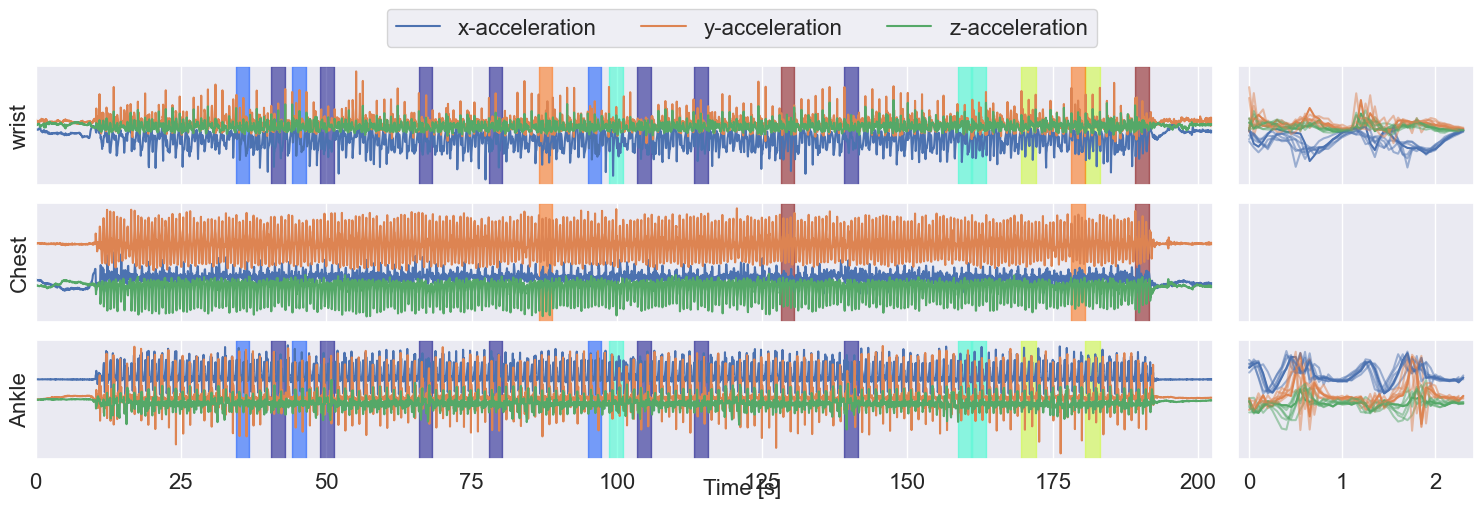

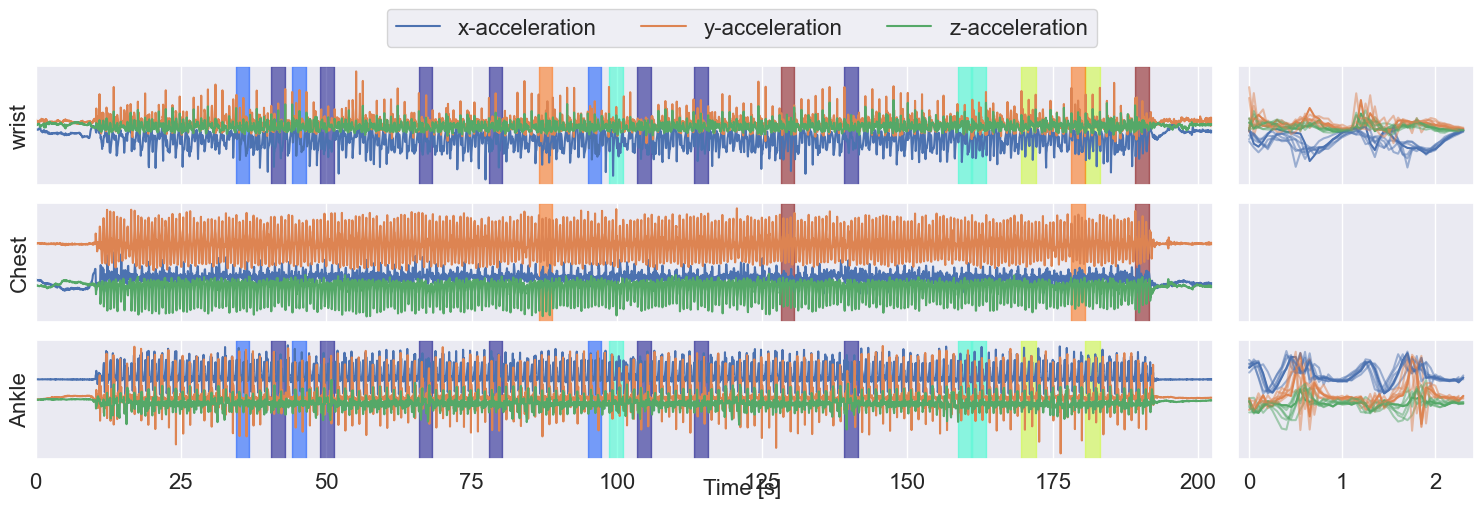

In [23]:
filtered_motifs_nordic_walking = size_constraint(all_motifs_nordic_walking, 2)
draw_figure(segments['Nordic walking'], segments_df['Nordic walking'].index, filtered_motifs_nordic_walking, motif_set_id=0)

### Walking vs. Nordic walking

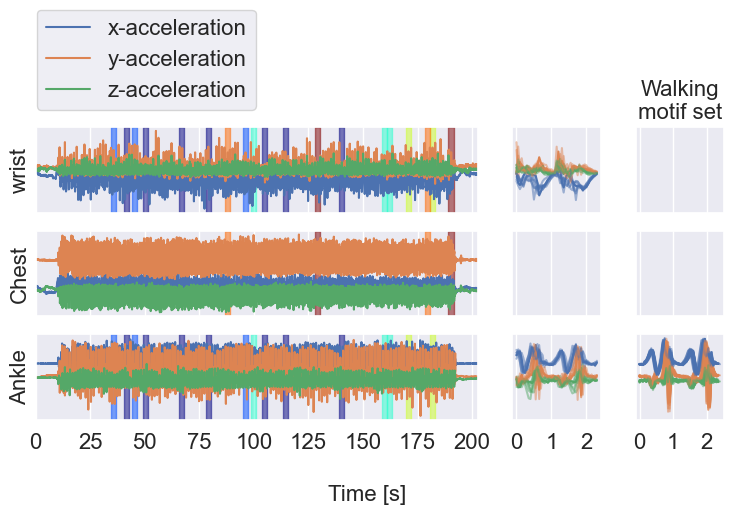

In [52]:
fig = draw_figure(segments['Nordic walking'], segments_df['Nordic walking'].index, filtered_motifs_nordic_walking, motif_set_id=0, other_motif_set=filtered_motifs_walking[0], other_X=segments['Walking'], x_ticks_motifs=[0, 1, 2], figsize=(7.5, 4))
fig.axes[2].set_title('Walking\nmotif set', fontsize=16)
save_figure(fig, 'nordic-walking-vs-walking')

### Cycling

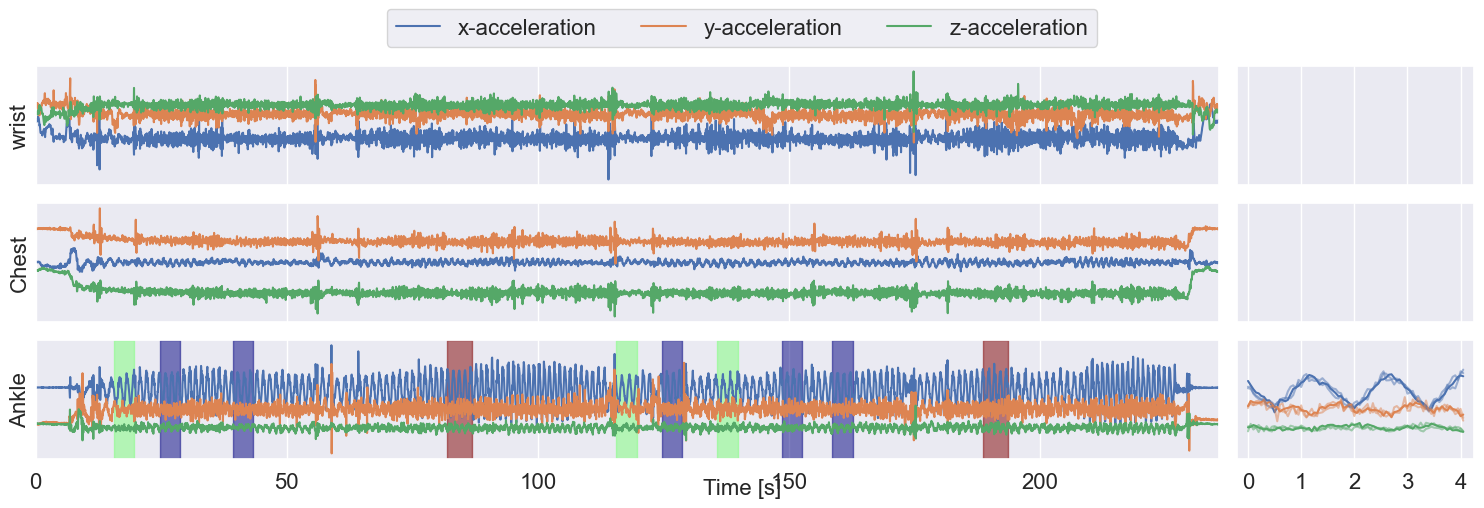

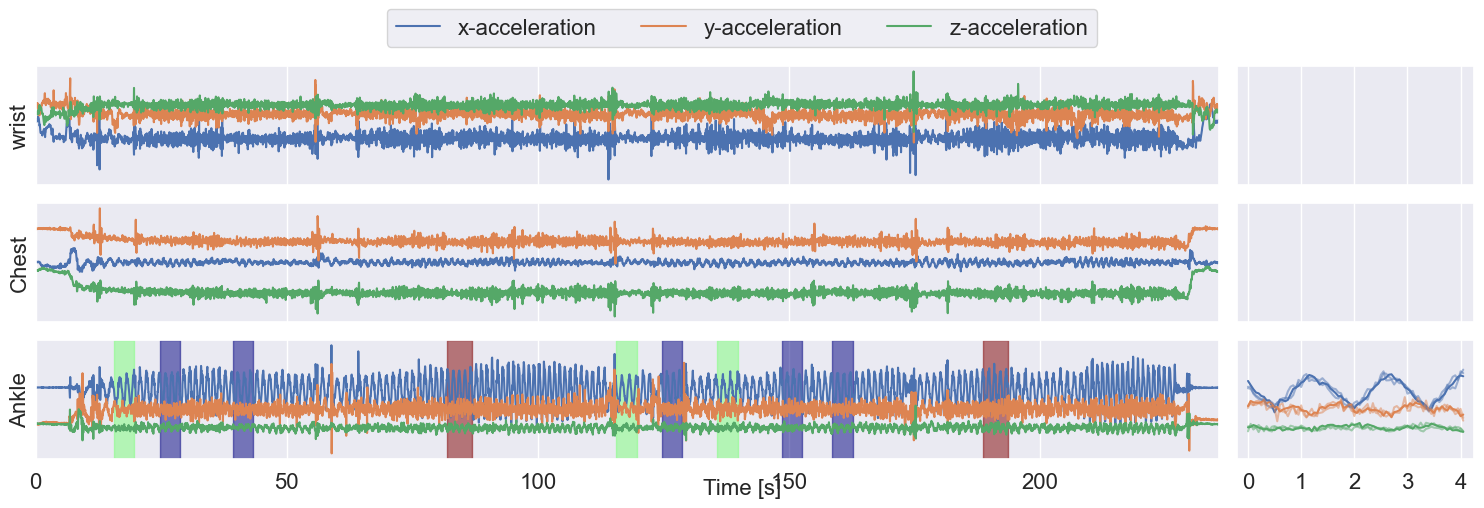

In [25]:
grouped_motifs_cycling = apply_locomotif_per_imu(
    segments['Cycling'],
    l_min=int(4*one_second_window),
    l_max=int(8*one_second_window),
    rho=0.8,
    warping=False,
    nb=3,
    margin=0.05
)
all_motifs_cycling = apply_sub_tsmd(
    grouped_motifs_cycling, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Cycling'], segments_df['Cycling'].index, all_motifs_cycling, motif_set_id=1)

### Running

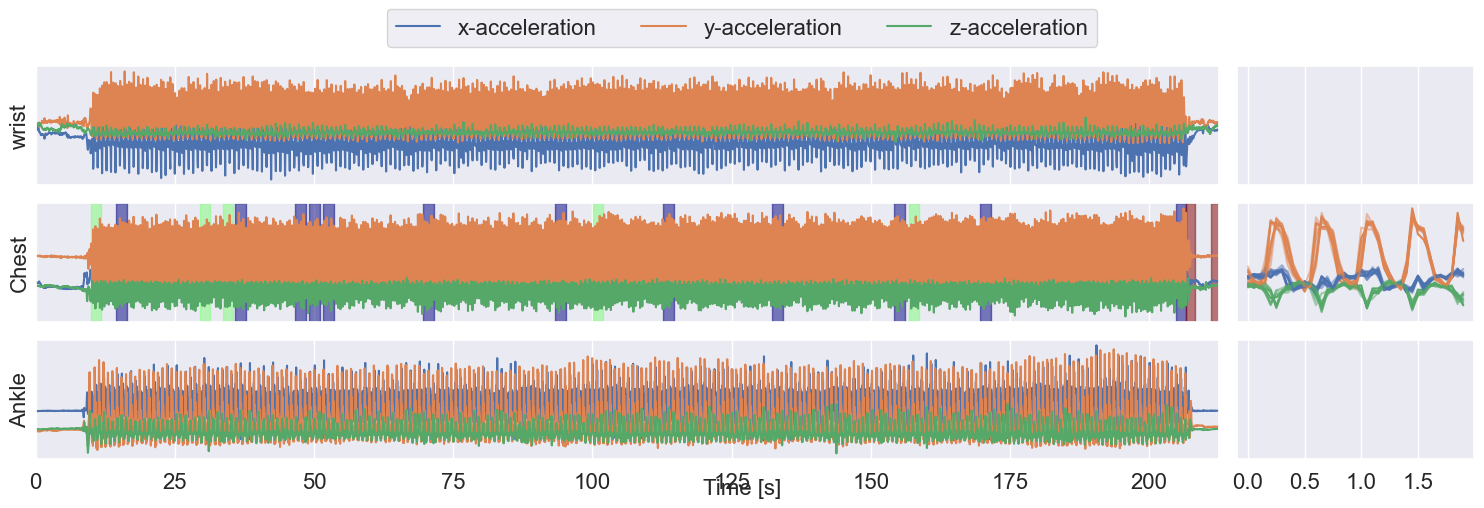

In [26]:
grouped_motifs_running= apply_locomotif_per_imu(
    segments['Running'],
    l_min=int(1*one_second_window),
    l_max=int(2*one_second_window),
    rho=0.7,
    warping=False,
    nb=3,
)
all_motifs_running = apply_sub_tsmd(
    grouped_motifs_running, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Running'], segments_df['Running'].index, all_motifs_running, motif_set_id=0);

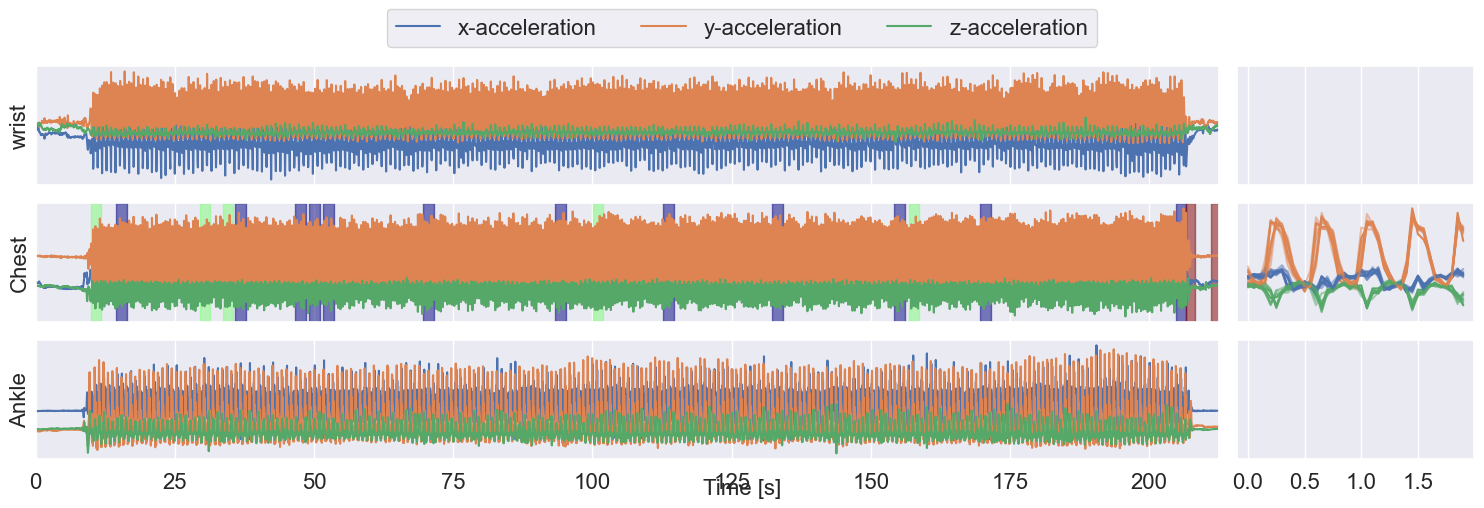

In [27]:
filtered_motifs_running = size_constraint(all_motifs_running, 1)
draw_figure(segments['Running'], segments_df['Running'].index, filtered_motifs_running, motif_set_id=0);

### Rope jumping

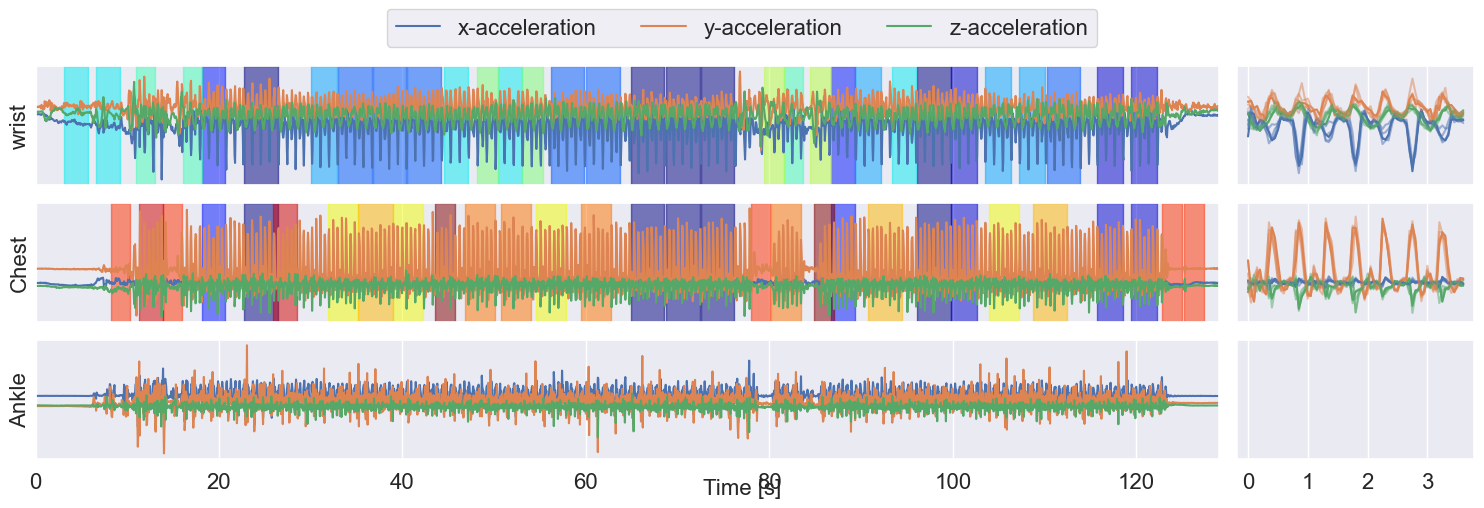

In [28]:
grouped_motifs_rope_jumping = apply_locomotif_per_imu(
    segments['Rope jumping'],
    l_min=int(2*one_second_window),
    l_max=int(4*one_second_window),
    rho=0.5,
    warping=False,
    margin=0.1
)
all_motifs_rope_jumping = apply_sub_tsmd(
    grouped_motifs_rope_jumping, 
    delta=0.5,
    linkage='average',
)
draw_figure(segments['Rope jumping'], segments_df['Rope jumping'].index, all_motifs_rope_jumping, motif_set_id=0);

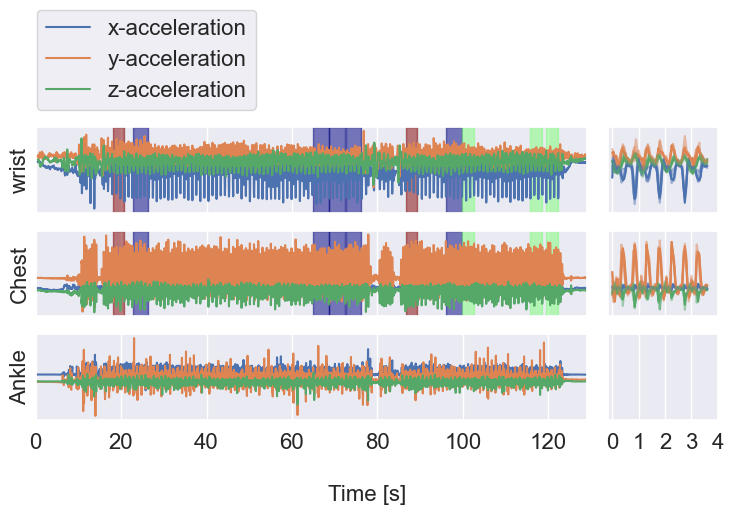

In [51]:
filtered_motifs_rope_jumping = size_constraint(all_motifs_rope_jumping, 2)
fig = draw_figure(segments['Rope jumping'], segments_df['Rope jumping'].index, filtered_motifs_rope_jumping, motif_set_id=0, x_ticks_motifs=[0, 1, 2, 3, 4], figsize=(7.5, 4))
save_figure(fig, 'rope-jumping')